In [10]:
import os, pickle, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("✅ Device:", device)

MODELS_DIR   = "../models"
RESULTS_DIR  = "../results/metrics"
FIGS_DIR     = "../results/figures"
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end','EFC_norm']
WINDOW = 20

# ── Load parquet + scaler ──────────────────────────────────────────────────────
ev_df = pd.read_parquet(f"{RESULTS_DIR}/ev_snippets_features.parquet")
with open(f"{RESULTS_DIR}/scaler_X_ev.pkl","rb") as f:
    scaler_X_ev = pickle.load(f)

print(f"Columns: {ev_df.columns.tolist()}")
print(f"'split' present: {'split' in ev_df.columns}")

# ── Rebuild split (same seed/logic as NB05 Cell 3) ────────────────────────────
if "split" not in ev_df.columns:
    from sklearn.model_selection import train_test_split
    np.random.seed(42)
    car_meta = ev_df.drop_duplicates("car")[["car","label","dataset"]].reset_index(drop=True)
    train_cars, temp_cars = train_test_split(
        car_meta, test_size=0.3, stratify=car_meta["label"], random_state=42)
    val_cars, test_cars = train_test_split(
        temp_cars, test_size=0.5, stratify=temp_cars["label"], random_state=42)

    train_ids = set(train_cars["car"])
    val_ids   = set(val_cars["car"])
    test_ids  = set(test_cars["car"])

    ev_df["split"] = ev_df["car"].map(
        lambda c: "train" if c in train_ids
                  else ("val" if c in val_ids else "test"))
    print("✅ Split column rebuilt")

for s in ["train","val","test"]:
    sub = ev_df[ev_df["split"]==s]
    print(f"  {s}: {sub['car'].nunique()} cars | {len(sub):,} snippets")

print(f"\n✅ EV data loaded: {ev_df.shape} | cars: {ev_df['car'].nunique()}")

✅ Device: mps
Columns: ['car', 'segment', 'label', 'dataset', 'cap_Ah', 'v_mean', 'v_min', 'v_slope', 'i_mean', 't_mean', 't_max', 'energy_Wh', 'duration_min', 'soc_start', 'soc_end', 'EFC_norm']
'split' present: False
✅ Split column rebuilt
  train: 321 cars | 731,353 snippets
  val: 69 cars | 165,045 snippets
  test: 69 cars | 179,374 snippets

✅ EV data loaded: (1075772, 17) | cars: 459


In [11]:
class HyperPILSTM(nn.Module):
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4, hyper_hidden=32):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.input_size  = input_size

        # Hypernetwork: EFC scalar → dynamic projection matrix (input_size × hidden_size)
        self.hypernet = nn.Sequential(
            nn.Linear(1, hyper_hidden),
            nn.ReLU(),
            nn.Linear(hyper_hidden, input_size * hidden_size),  # → 12*64 = 768
        )

        # Normalise the dynamically projected features
        self.proj_norm = nn.LayerNorm(hidden_size)

        # h0 generator: EFC scalar → initial hidden state
        self.h0_embed = nn.Sequential(
            nn.Linear(1, hidden_size),                          # → (B, 64)
        )

        # LSTM receives projected features (hidden_size-dim input)
        self.lstm = nn.LSTM(
            input_size=hidden_size, hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16),          nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def get_embedding(self, x, efc_norm):
        B, T, _ = x.shape

        # Generate dynamic projection matrix from EFC
        W = self.hypernet(efc_norm.unsqueeze(-1))         # (B, input_size*hidden_size)
        W = W.view(B, self.input_size, self.hidden_size)  # (B, 12, 64)

        # Project raw features: (B, T, 12) @ (B, 12, 64) → (B, T, 64)
        x_proj = torch.bmm(x, W)
        x_proj = self.proj_norm(x_proj)                   # (B, T, 64)

        # Initial hidden state from EFC
        h0 = self.h0_embed(efc_norm.unsqueeze(-1))        # (B, 64)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        out, _ = self.lstm(x_proj, (h0, c0))
        return out[:, -1, :]                              # (B, 64)

    def forward(self, x, efc_norm):
        return self.fc(self.get_embedding(x, efc_norm)).squeeze(-1)

In [12]:
class EVClassifier(nn.Module):
    def __init__(self, backbone, freeze_encoder=True):
        super().__init__()
        self.backbone = deepcopy(backbone)
        if freeze_encoder:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(backbone.hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, efc_norm):
        emb = self.backbone.get_embedding(x, efc_norm)
        return self.classifier(emb).squeeze(-1)

print("✅ EVClassifier defined")

✅ EVClassifier defined


In [13]:
def train_one_model(model, train_loader, val_loader,
                    lr=3e-4, epochs=40, patience=8,
                    save_path=None, label="model"):
    opt   = torch.optim.Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_val, patience_c = float("inf"), 0
    hist = {"train": [], "val": [], "auc": []}

    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0.0
        for xb,yb,efc,_ in train_loader:
            xb,yb,efc = xb.to(device), yb.float().to(device), efc.to(device)
            opt.zero_grad()
            loss = criterion(model(xb,efc), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss, logits_v, labels_v = 0.0, [], []
        with torch.no_grad():
            for xb,yb,efc,_ in val_loader:
                xb,yb,efc = xb.to(device), yb.float().to(device), efc.to(device)
                lg = model(xb,efc)
                val_loss += criterion(lg, yb).item()
                logits_v.extend(lg.cpu().numpy())
                labels_v.extend(yb.cpu().numpy())
        val_loss /= len(val_loader)
        auc = roc_auc_score(labels_v, logits_v)
        sched.step(val_loss)

        hist["train"].append(train_loss)
        hist["val"].append(val_loss)
        hist["auc"].append(auc)

        if val_loss < best_val - 1e-4:
            best_val, patience_c = val_loss, 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            patience_c += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"{label} Epoch {epoch:2d}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"AUC={auc:.4f}  patience={patience_c}/{patience}")

        if patience_c >= patience:
            print(f"{label} Early stop @ epoch {epoch}")
            break

    return hist, best_val


def car_level_eval(model, loader):
    """Returns car-level AUC and balanced accuracy."""
    model.eval()
    rows = []
    with torch.no_grad():
        for xb,yb,efc,cids in loader:
            xb,efc = xb.to(device), efc.to(device)
            probs = torch.sigmoid(model(xb,efc)).cpu().numpy()
            for i,cid in enumerate(cids):
                rows.append({"car": cid,
                             "label": int(yb[i]),
                             "prob":  float(probs[i])})
    df = (pd.DataFrame(rows)
            .groupby("car")
            .agg(label=("label","first"), mean_prob=("prob","mean"))
            .reset_index())
    auc     = roc_auc_score(df["label"], df["mean_prob"])
    preds   = (df["mean_prob"] > 0.5).astype(int)
    bal_acc = balanced_accuracy_score(df["label"], preds)
    return auc, bal_acc, df


print("✅ Helpers defined")

✅ Helpers defined


In [14]:
state = torch.load(f"{MODELS_DIR}/best_hyperpilstm.pt", map_location="cpu")
for k, v in state.items():
    print(f"{k:45s}  {tuple(v.shape)}")

hypernet.0.weight                              (32, 1)
hypernet.0.bias                                (32,)
hypernet.2.weight                              (768, 32)
hypernet.2.bias                                (768,)
proj_norm.weight                               (64,)
proj_norm.bias                                 (64,)
h0_embed.0.weight                              (64, 1)
h0_embed.0.bias                                (64,)
lstm.weight_ih_l0                              (256, 64)
lstm.weight_hh_l0                              (256, 64)
lstm.bias_ih_l0                                (256,)
lstm.bias_hh_l0                                (256,)
lstm.weight_ih_l1                              (256, 64)
lstm.weight_hh_l1                              (256, 64)
lstm.bias_ih_l1                                (256,)
lstm.bias_hh_l1                                (256,)
fc.0.weight                                    (32, 64)
fc.0.bias                                      (32,)
fc.3.weight   

In [16]:
class EVDataset(torch.utils.data.Dataset):
    def __init__(self, df, feature_cols, window, scaler):
        self.samples = []
        for car_id, grp in df.groupby("car"):
            X = scaler.transform(grp[feature_cols].values)
            label = int(grp["label"].iloc[0])
            efc   = float(grp["EFC_norm"].iloc[0])
            for i in range(0, len(X) - window + 1, window):
                self.samples.append((
                    X[i:i+window].astype(np.float32),
                    label,
                    np.float32(efc),
                    car_id
                ))

    def __len__(self):  return len(self.samples)
    def __getitem__(self, idx):
        x, y, efc, car = self.samples[idx]
        return torch.tensor(x), torch.tensor(y), torch.tensor(efc), car

print("✅ EVDataset defined")

✅ EVDataset defined


In [17]:
train_ds = EVDataset(ev_df[ev_df["split"]=="train"], FEATURE_COLS, WINDOW, scaler_X_ev)
val_ds   = EVDataset(ev_df[ev_df["split"]=="val"],   FEATURE_COLS, WINDOW, scaler_X_ev)
test_ds  = EVDataset(ev_df[ev_df["split"]=="test"],  FEATURE_COLS, WINDOW, scaler_X_ev)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=0)

criterion = torch.nn.BCEWithLogitsLoss()

print(f"✅ Loaders ready | train={len(train_ds):,}  val={len(val_ds):,}  test={len(test_ds):,}")

/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/pytho

✅ Loaders ready | train=36,425  val=8,222  test=8,934


/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/battery_rul/lib/pytho

In [18]:
print("="*55)
print("① ZERO-SHOT — lab model, zero EV fine-tuning")
print("="*55)

# Load pre-trained HyperPILSTM from NB03/NB04
lab_model = HyperPILSTM(input_size=12, hidden_size=64,
                        num_layers=2, dropout=0.4,
                        hyper_hidden=32).to(device)
lab_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/best_hyperpilstm.pt", map_location=device))

# Wrap with a *frozen* EV classifier head (head is random / untrained)
# → purely tests what the HyperPILSTM encoder already knows about EV degradation
zero_shot_model = EVClassifier(lab_model, freeze_encoder=True).to(device)

auc_zs, bal_zs, _ = car_level_eval(zero_shot_model, test_loader)
print(f"Car-level AUC          {auc_zs:.4f}")
print(f"Car-level Balanced Acc {bal_zs:.4f}")
print("(random head — purely tests encoder representation quality)")

① ZERO-SHOT — lab model, zero EV fine-tuning
Car-level AUC          0.3669
Car-level Balanced Acc 0.4207
(random head — purely tests encoder representation quality)


In [19]:
print("="*55)
print("② SCRATCH — same architecture, random init")
print("="*55)

# Random HyperPILSTM — no pretrained weights
scratch_base  = HyperPILSTM(input_size=12, hidden_size=64,
                             num_layers=2, dropout=0.4,
                             hyper_hidden=32).to(device)
scratch_model = EVClassifier(scratch_base, freeze_encoder=False).to(device)

print(f"Params {sum(p.numel() for p in scratch_model.parameters()):,} "
      f"(all trainable, no pretrained weights)")

hist_scratch, bv_scratch = train_one_model(
    scratch_model, train_loader, val_loader,
    lr=3e-4, epochs=40, patience=8,
    save_path=f"{MODELS_DIR}/ablation_scratch.pt",
    label="SCRATCH",
)

scratch_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_scratch.pt", map_location=device))
auc_sc, bal_sc, _ = car_level_eval(scratch_model, test_loader)
print(f"Car-level AUC          {auc_sc:.4f}")
print(f"Car-level Balanced Acc {bal_sc:.4f}")

② SCRATCH — same architecture, random init
Params 96,962 (all trainable, no pretrained weights)
SCRATCH Epoch  1  train=0.5233  val=0.2559  AUC=0.4903  patience=0/8
SCRATCH Epoch  5  train=0.1998  val=0.2525  AUC=0.7775  patience=2/8
SCRATCH Epoch 10  train=0.1179  val=0.2179  AUC=0.8084  patience=0/8
SCRATCH Epoch 15  train=0.0976  val=0.2596  AUC=0.8021  patience=3/8
SCRATCH Epoch 20  train=0.0895  val=0.2457  AUC=0.8160  patience=8/8
SCRATCH Early stop @ epoch 20
Car-level AUC          0.8837
Car-level Balanced Acc 0.7423


In [20]:
print("="*55)
print("③ FROZEN TL — pretrained encoder, head only")
print("="*55)

frozen_model = EVClassifier(lab_model, freeze_encoder=True).to(device)
n_trainable  = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"Trainable params {n_trainable:,} (head only)")

hist_frozen, bv_frozen = train_one_model(
    frozen_model, train_loader, val_loader,
    lr=1e-3, epochs=30, patience=5,
    save_path=f"{MODELS_DIR}/ablation_frozen.pt",
    label="FROZEN",
)

frozen_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_frozen.pt", map_location=device))
auc_fr, bal_fr, _ = car_level_eval(frozen_model, test_loader)
print(f"Car-level AUC          {auc_fr:.4f}")
print(f"Car-level Balanced Acc {bal_fr:.4f}")

③ FROZEN TL — pretrained encoder, head only
Trainable params 2,113 (head only)
FROZEN Epoch  1  train=0.4771  val=0.3014  AUC=0.4951  patience=0/5
FROZEN Epoch  5  train=0.3398  val=0.2548  AUC=0.5284  patience=0/5
FROZEN Epoch 10  train=0.3286  val=0.2439  AUC=0.5731  patience=0/5
FROZEN Epoch 15  train=0.3283  val=0.2443  AUC=0.5997  patience=1/5
FROZEN Epoch 20  train=0.3267  val=0.2437  AUC=0.6195  patience=2/5
FROZEN Early stop @ epoch 23
Car-level AUC          0.7213
Car-level Balanced Acc 0.5000


In [21]:
import os
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f"{MODELS_DIR}/{f}") / 1e6
    print(f"{f:45s}  {size:.1f} MB")

ablation_frozen.pt                             0.4 MB
ablation_scratch.pt                            0.4 MB
best_hyperpilstm.pt                            0.4 MB
best_pilstm_final.pt                           0.2 MB
best_pilstm_v2.pt                              0.4 MB
ev_cls_frozen.pt                               0.4 MB
ev_cls_full_ft.pt                              0.4 MB


In [22]:
print("="*55)
print("④ FULL TL — pretrained encoder + full fine-tune")
print("="*55)

full_ft_model = EVClassifier(lab_model, freeze_encoder=False).to(device)
print(f"Params {sum(p.numel() for p in full_ft_model.parameters()):,} (all trainable)")

hist_full_ft, bv_full_ft = train_one_model(
    full_ft_model, train_loader, val_loader,
    lr=3e-4, epochs=40, patience=8,
    save_path=f"{MODELS_DIR}/ev_cls_hyperpilstm.pt",
    label="FULL TL",
)

full_ft_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ev_cls_hyperpilstm.pt", map_location=device))
auc_ft, bal_ft, car_df_ft = car_level_eval(full_ft_model, test_loader)
print(f"Car-level AUC          {auc_ft:.4f}")
print(f"Car-level Balanced Acc {bal_ft:.4f}")

④ FULL TL — pretrained encoder + full fine-tune
Params 96,962 (all trainable)
FULL TL Epoch  1  train=0.5090  val=0.3292  AUC=0.4968  patience=0/8
FULL TL Epoch  5  train=0.2266  val=0.2198  AUC=0.8018  patience=1/8
FULL TL Epoch 10  train=0.1440  val=0.2320  AUC=0.8375  patience=4/8
FULL TL Early stop @ epoch 14
Car-level AUC          0.8988
Car-level Balanced Acc 0.7604


In [23]:
print("="*55)
print("⑤ PLAIN LSTM — no EFC conditioning (scratch)")
print("="*55)

class PlainLSTMClassifier(nn.Module):
    """Vanilla LSTM — EFC_norm is never used."""
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x, efc_norm=None):   # efc_norm intentionally ignored
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :]).squeeze(-1)

lstm_model = PlainLSTMClassifier().to(device)
print(f"Params {sum(p.numel() for p in lstm_model.parameters()):,}")

hist_lstm, _ = train_one_model(
    lstm_model, train_loader, val_loader,
    lr=3e-4, epochs=40, patience=8,
    save_path=f"{MODELS_DIR}/ablation_plain_lstm.pt",
    label="PLAIN LSTM",
)
lstm_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_plain_lstm.pt", map_location=device))
auc_lstm, bal_lstm, _ = car_level_eval(lstm_model, test_loader)
print(f"Car-level AUC          {auc_lstm:.4f}")
print(f"Car-level Balanced Acc {bal_lstm:.4f}")


print()
print("="*55)
print("⑥ PILSTM Classifier — trained from scratch")
print("="*55)

class PILSTMClassifier(nn.Module):
    """PILSTM architecture from NB03, adapted for binary classification."""
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4):
        super().__init__()
        self.num_layers  = num_layers
        self.hidden_size = hidden_size
        self.h0_embed = nn.Sequential(nn.Linear(1, hidden_size), nn.Tanh())
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x, efc_norm):
        h0 = self.h0_embed(efc_norm.unsqueeze(-1))
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.classifier(out[:, -1, :]).squeeze(-1)

pilstm_model = PILSTMClassifier().to(device)
print(f"Params {sum(p.numel() for p in pilstm_model.parameters()):,} (trained from scratch)")

hist_pi, _ = train_one_model(
    pilstm_model, train_loader, val_loader,
    lr=3e-4, epochs=40, patience=8,
    save_path=f"{MODELS_DIR}/ablation_pilstm_scratch.pt",
    label="PILSTM (scratch)",
)
pilstm_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/ablation_pilstm_scratch.pt", map_location=device))
auc_pi, bal_pi, _ = car_level_eval(pilstm_model, test_loader)
print(f"Car-level AUC          {auc_pi:.4f}")
print(f"Car-level Balanced Acc {bal_pi:.4f}")

⑤ PLAIN LSTM — no EFC conditioning (scratch)
Params 55,361
PLAIN LSTM Epoch  1  train=0.6245  val=0.2607  AUC=0.5931  patience=0/8
PLAIN LSTM Epoch  5  train=0.2530  val=0.2157  AUC=0.7255  patience=0/8
PLAIN LSTM Epoch 10  train=0.1979  val=0.2255  AUC=0.7230  patience=5/8
PLAIN LSTM Early stop @ epoch 13
Car-level AUC          0.8925
Car-level Balanced Acc 0.6857

⑥ PILSTM Classifier — trained from scratch
Params 55,489 (trained from scratch)
PILSTM (scratch) Epoch  1  train=0.5685  val=0.2418  AUC=0.6081  patience=0/8
PILSTM (scratch) Epoch  5  train=0.2418  val=0.2193  AUC=0.7457  patience=0/8
PILSTM (scratch) Epoch 10  train=0.2063  val=0.2251  AUC=0.7522  patience=5/8
PILSTM (scratch) Early stop @ epoch 13
Car-level AUC          0.9009
Car-level Balanced Acc 0.6836


                                                            
ABLATION STUDY — Car-level EV Degradation Detection
Condition                             AUC   Bal. Acc
------------------------------------------------------------
Zero-shot (no fine-tune)           0.3669     0.4207
Scratch (HyperPI random)           0.8837     0.7423
Frozen TL (head only)              0.7213     0.5000
Plain LSTM (no EFC, scr.)          0.8925     0.6857
PILSTM (full TL)                   0.9009     0.6836
HyperPILSTM (full TL ours)         0.8988     0.7604 ★


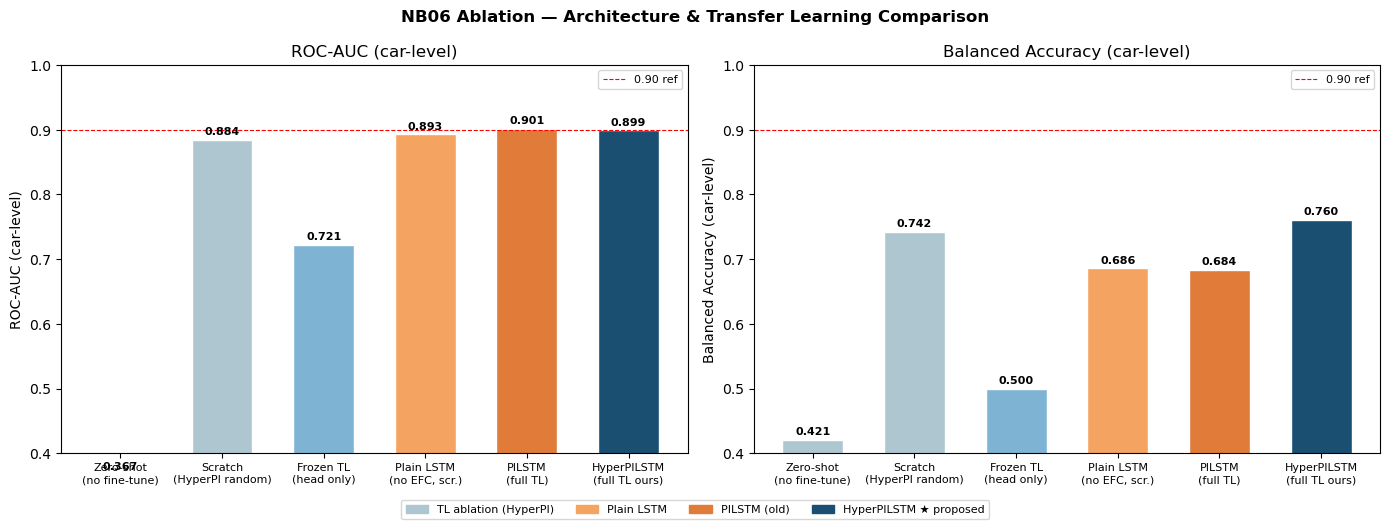

Saved → results/figures/ablation_barchart.png


In [24]:
results = {
    "Zero-shot\n(no fine-tune)":   (auc_zs,   bal_zs),
    "Scratch\n(HyperPI random)":   (auc_sc,   bal_sc),
    "Frozen TL\n(head only)":      (auc_fr,   bal_fr),
    "Plain LSTM\n(no EFC, scr.)":  (auc_lstm, bal_lstm),
    "PILSTM\n(full TL)":           (auc_pi,   bal_pi),
    "HyperPILSTM\n(full TL ours)": (auc_ft,   bal_ft),
}

print(" "*60)
print("ABLATION STUDY — Car-level EV Degradation Detection")
print("="*60)
print(f"{'Condition':<32} {'AUC':>8} {'Bal. Acc':>10}")
print("-"*60)
for cond, (auc, bal) in results.items():
    name   = cond.replace("\n", " ")
    marker = " ★" if "ours" in cond else ""
    print(f"{name:<32} {auc:>8.4f} {bal:>10.4f}{marker}")
print("="*60)

# Bar chart
labels = list(results.keys())
aucs   = [v[0] for v in results.values()]
bals   = [v[1] for v in results.values()]
colors = ["#aec6cf","#aec6cf","#7fb3d3",   # TL ablation group
          "#f4a460","#e07b39",              # architecture group
          "#1a4f72"]                        # proposed

x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, title in zip(
        axes, [aucs, bals],
        ["ROC-AUC (car-level)", "Balanced Accuracy (car-level)"]):
    bars = ax.bar(x, vals, color=colors, edgecolor="white", width=0.6)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0.4, 1.0); ax.set_ylabel(title); ax.set_title(title)
    ax.axhline(0.9, color="red", linestyle="--", linewidth=0.8, label="0.90 ref")
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Legend patches
patches = [
    mpatches.Patch(color="#aec6cf", label="TL ablation (HyperPI)"),
    mpatches.Patch(color="#f4a460", label="Plain LSTM"),
    mpatches.Patch(color="#e07b39", label="PILSTM (old)"),
    mpatches.Patch(color="#1a4f72", label="HyperPILSTM ★ proposed"),
]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("NB06 Ablation — Architecture & Transfer Learning Comparison",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ablation_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/ablation_barchart.png")

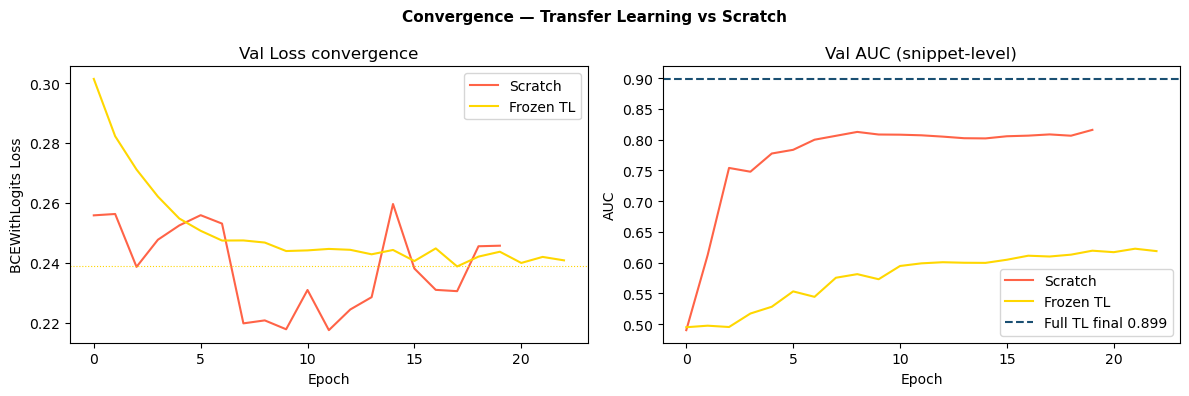

Saved → results/metrics/ablation_results.csv


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_scratch["val"], label="Scratch",   color="tomato")
axes[0].plot(hist_frozen["val"],  label="Frozen TL", color="gold")
axes[0].axhline(bv_frozen, color="gold", linestyle=":", linewidth=0.8)
axes[0].set_title("Val Loss convergence")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCEWithLogits Loss")
axes[0].legend()

axes[1].plot(hist_scratch["auc"], label="Scratch",   color="tomato")
axes[1].plot(hist_frozen["auc"],  label="Frozen TL", color="gold")
axes[1].axhline(auc_ft, color="#1a4f72", linestyle="--",
                label=f"Full TL final {auc_ft:.3f}", linewidth=1.5)
axes[1].set_title("Val AUC (snippet-level)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].legend()

plt.suptitle("Convergence — Transfer Learning vs Scratch",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/ablation_convergence.png", dpi=150)
plt.show()

# Save table to CSV
rows = []
for cond, (auc, bal) in results.items():
    rows.append({"condition": cond.replace("\n"," "), "AUC": auc, "BalAcc": bal})
pd.DataFrame(rows).to_csv(f"{RESULTS_DIR}/ablation_results.csv", index=False)
print(f"Saved → results/metrics/ablation_results.csv")